# GASMAS Signal Analysis - Internal Illumination

External-detector sweeps over the O₂ A-band for the layered thorax phantom
at source–detector separations of 25 mm, 50 mm, 65 mm, plus a short-path
reference (`ref`).

**Pipeline (per dataset)**
1. Load raw `.dat`, scale to absolute signal (1/amplification).
2. Truncate to the sweep window of interest.
3. Savitzky–Golay smoothing.
4. Polynomial baseline from the two ends (dip region excluded).
5. Compute the baseline-corrected absorption peak  $c = b - s$  and the
   normalized dip  $d = c / s_0$  at the dip location.
6. Propagate uncertainty in $d$ from (a) measurement noise and
   (b) baseline-fit uncertainty.


## 1. Setup and data loading

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Colab mount — comment out if running locally
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
internal_dir = '/content/drive/MyDrive/GASMAS data/GASMAS2026/19May_26/F1/internal/45mm_H'
internal_dir_2 = '/content/drive/MyDrive/GASMAS data/GASMAS2026/19May_26/F1/internal/60mm_H'

"""
# Check if the folder exists
if os.path.exists(internal_dir) and os.path.isdir(internal_dir):
    # List all files and directories in the 'external' folder
    files_in_internal = os.listdir(internal_dir)
    print(f"Files in '{internal_dir}':")
    for item in files_in_internal:
        print(item)
else:
    print(f"The folder '{internal_dir}' does not exist or is not a directory.")"""

'\n# Check if the folder exists\nif os.path.exists(internal_dir) and os.path.isdir(internal_dir):\n    # List all files and directories in the \'external\' folder\n    files_in_internal = os.listdir(internal_dir)\n    print(f"Files in \'{internal_dir}\':")\n    for item in files_in_internal:\n        print(item)\nelse:\n    print(f"The folder \'{internal_dir}\' does not exist or is not a directory.")'

In [ ]:
FILES45 = {
    '30_45H': ('F1--lastPhantom_int_1e6_30_45mm200S-19052026.dat',  1e-6),
    '45_45H': ('F1--lastPhantom_int_1e8_45_45mm_200S-19052026.dat',  1e-8), # Corrected filename and gain
    '60_45H': ('F1--lastPhantom_int_1e8_60_45mm_200S-19052026.dat',  1e-8),
}
FILES60 = {
    '30_60H': ('F1--lastPhantom_int_1e8_30_60mm_200S-19052026.dat',  1e-8),
    '50_60H': ('F1--lastPhantom_int_1e7_50_60mm_200S-19052026.dat',  1e-7), # Corrected filename and gain
    '45_60H_ref': ('F1--lastPhantom_int_1e7_45_60mm_200S_WES-19052026.dat',  1e-7),
}

In [ ]:
# Load raw data into a dict of (time, signal) tuples
def load_dat(filename, gain,dir):
    arr = np.loadtxt(os.path.join(dir, filename))
    return arr[:, 0], arr[:, 1] * gain

raw = {label: load_dat(fname, gain,internal_dir) for label, (fname, gain) in FILES45.items()}
raw.update({label: load_dat(fname, gain,internal_dir_2) for label, (fname, gain) in FILES60.items()})

for label, (t, s) in raw.items():
    print(f'{label:>5s}: {len(t)} samples, t ∈ [{t.min():.4f}, {t.max():.4f}] s, '
          f'signal range [{s.min():.3e}, {s.max():.3e}]')

30_45H: 24877 samples, t ∈ [-0.0227, 0.0768] s, signal range [1.384e-07, 1.575e-07]
45_45H: 24877 samples, t ∈ [-0.0227, 0.0768] s, signal range [7.840e-09, 8.983e-09]
60_45H: 24877 samples, t ∈ [-0.0227, 0.0768] s, signal range [4.682e-10, 5.444e-10]
30_60H: 24877 samples, t ∈ [-0.0227, 0.0768] s, signal range [1.081e-08, 1.228e-08]
50_60H: 24877 samples, t ∈ [-0.0227, 0.0768] s, signal range [4.886e-09, 5.659e-09]
45_60H_ref: 24877 samples, t ∈ [-0.0227, 0.0768] s, signal range [8.857e-08, 9.896e-08]


## 2. Quick look at all four raw sweeps

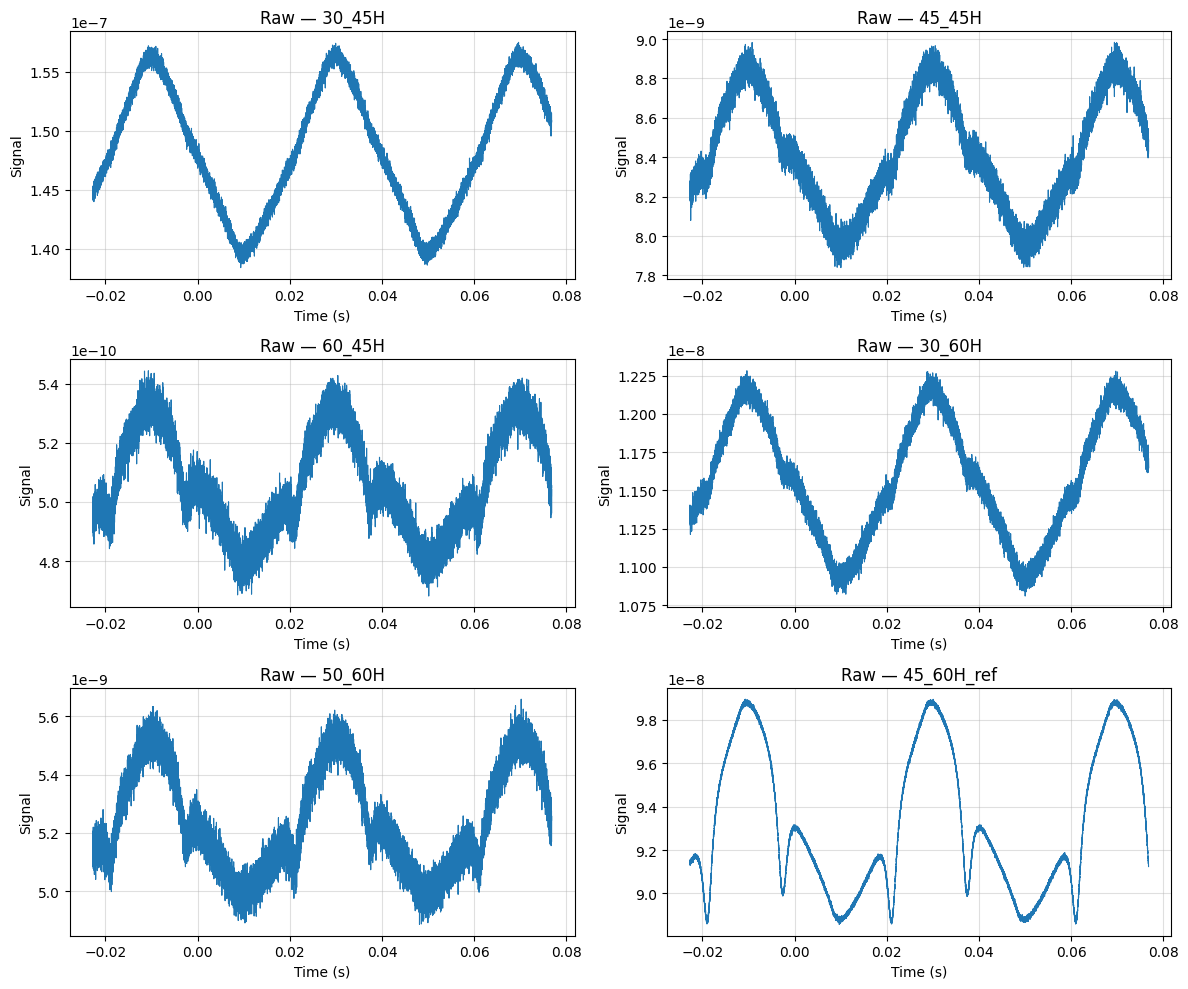

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=False)
for ax, (label, (t, s)) in zip(axes.flat, raw.items()):
    ax.plot(t, s, lw=0.8)
    ax.set_title(f'Raw — {label}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Signal')
    ax.grid(True, alpha=0.4)
fig.tight_layout()
plt.show()

## 3. Processing function

Single function that does truncation → Savitzky–Golay smoothing →
polynomial baseline → corrected and normalized dip, and returns


In [ ]:
def process_signal(
    time_data,
    signal_data,
    start_time,
    end_time,
    savgol_window_length=51,
    savgol_polyorder=3,
    baseline_fit_fraction=0.25,
    baseline_poly_degree=3,
):
    """Truncate, smooth, baseline-correct, and normalize one GASMAS sweep.

    Parameters
    ----------
    time_data, signal_data : 1-D arrays of equal length.
    start_time, end_time   : truncation window (seconds).
    savgol_window_length   : odd integer; Savitzky–Golay window.
    savgol_polyorder       : polyorder for Savitzky–Golay.
    baseline_fit_fraction  : fraction of points at each end used to fit
                             the baseline. The middle (1 - 2*f) is treated
                             as the dip region and excluded from the fit.
    baseline_poly_degree   : polynomial degree for the baseline fit.

    Returns
    -------
    dict with keys:
        time         : truncated time axis
        raw          : truncated raw signal
        smoothed     : Savitzky–Golay smoothed signal
        baseline     : fitted baseline evaluated on `time`
        corrected    : b - s  (positive absorption peak)
        normalized   : corrected / s0
        dip_idx      : index of the maximum of `corrected`
        s0           : baseline value at the dip location
        norm_dip     : scalar peak value of `normalized`
        sigma_noise  : per-point measurement noise estimated from the
                       baseline regions only (std of raw - smoothed there)
        baseline_cov : covariance matrix of the polynomial baseline
                       coefficients, from np.polyfit(..., cov=True)
        baseline_powers : powers used to build the design row for s0's
                       variance (matches np.polyval convention)
    """
    # 1. Truncate
    m = (time_data >= start_time) & (time_data <= end_time)
    t = time_data[m]
    s_raw = signal_data[m]

    # 2. Savitzky–Golay smoothing (with safe fallback for short signals)
    w = savgol_window_length
    p = savgol_polyorder
    if len(s_raw) < w:
        w = len(s_raw) if len(s_raw) % 2 == 1 else len(s_raw) - 1
        if w < p + 2:
            print('Warning: signal too short for Savitzky–Golay; skipping.')
            s_smooth = s_raw.copy()
        else:
            s_smooth = savgol_filter(s_raw, w, p)
    else:
        s_smooth = savgol_filter(s_raw, w, p)

    # 3. Baseline fit using the two ends only (dip region excluded)
    n = len(t)
    n_end = int(n * baseline_fit_fraction)
    # boolean mask of points used for the baseline fit
    base_mask = np.zeros(n, dtype=bool)
    base_mask[:n_end] = True
    base_mask[n - n_end:] = True

    coeffs, cov = np.polyfit(
        t[base_mask], s_smooth[base_mask], baseline_poly_degree, cov=True
    )
    baseline = np.polyval(coeffs, t)

    # 4. Corrected (b - s ⇒ positive in the absorbing region) and normalized
    corrected = -(s_smooth - baseline)
    dip_idx = int(np.argmax(corrected))
    s0 = baseline[dip_idx]
    normalized = corrected / s0
    norm_dip = float(normalized[dip_idx])

    # 5. Noise from baseline regions only — uncontaminated by the dip
    resid_base = s_raw[base_mask] - s_smooth[base_mask]
    sigma_noise = float(np.std(resid_base, ddof=1))

    # Powers vector at the dip time, for propagating coeff covariance to s0:
    #   s0 = sum_k coeffs[k] * t_dip ** (deg - k)
    deg = baseline_poly_degree
    t_dip = t[dip_idx]
    powers = np.array([t_dip ** (deg - k) for k in range(deg + 1)])

    return {
        'time':            t,
        'raw':             s_raw,
        'smoothed':        s_smooth,
        'baseline':        baseline,
        'corrected':       corrected,
        'normalized':      normalized,
        'dip_idx':         dip_idx,
        's0':              s0,
        'norm_dip':        norm_dip,
        'sigma_noise':     sigma_noise,
        'baseline_cov':    cov,
        'baseline_powers': powers,
    }


def plot_processing(result, label):
    """Three-panel diagnostic: raw+smoothed, smoothed+baseline, normalized."""
    t = result['time']
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(t, result['raw'], lw=0.8, alpha=0.6, label='raw')
    axes[0].plot(t, result['smoothed'], 'r', lw=1.2, label='Savitzky–Golay')
    axes[0].set_ylabel('Signal',fontsize=16)
    #axes[0].set_title(f'{label} — smoothing')

    axes[1].plot(t, result['smoothed'], 'b', alpha=0.7, label='smoothed')
    axes[1].plot(t, result['baseline'], 'g--', lw=1.2, label='baseline fit')
    axes[1].set_ylabel('Signal',fontsize=16)
    #axes[1].axvline(t[result['dip_idx']], color='k', lw=0.6, alpha=0.5)
    #axes[1].set_title(f'{label} — baseline')

    axes[2].plot(t, result['normalized'], 'r')
    axes[2].set_ylabel('$S_{rel}$',fontsize=18)
    axes[2].tick_params(axis='x', labelsize=12)
    axes[2].tick_params(axis='y', labelsize=12)
    #axes[2].axvline(t[result['dip_idx']], color='k', lw=0.6, alpha=0.5)
    #axes[2].set_title(f'{label} — normalized,  d = {result["norm_dip"]:.3e}')

    for ax in axes:
        ax.set_xlabel('Time (s)',fontsize=18)

        ax.grid(True, alpha=0.4)
        ax.legend(fontsize=12)
    fig.tight_layout()
    plt.show()

## 4. Per-dataset processing



/tmp/ipykernel_11187/3781488794.py:134: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12)


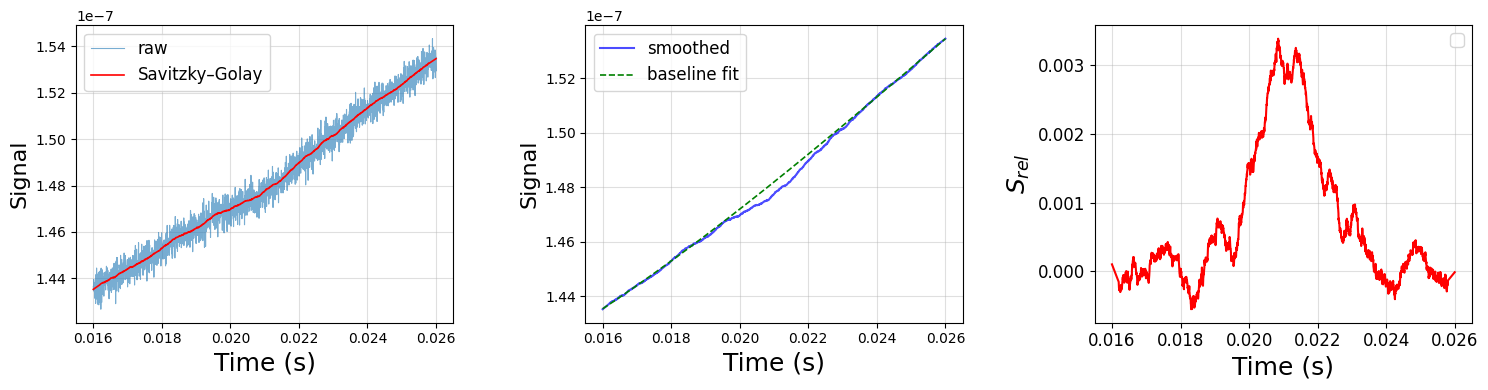

30_45H: norm_dip = 3.3895e-03   s0 = 1.4805e-07   sigma_noise = 3.577e-10



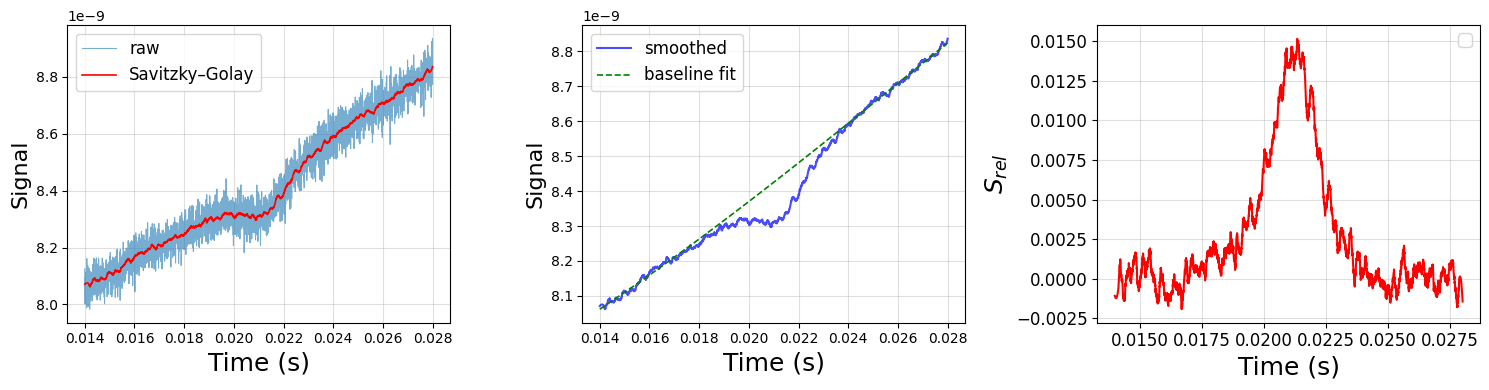

45_45H: norm_dip = 1.5154e-02   s0 = 8.4439e-09   sigma_noise = 3.719e-11



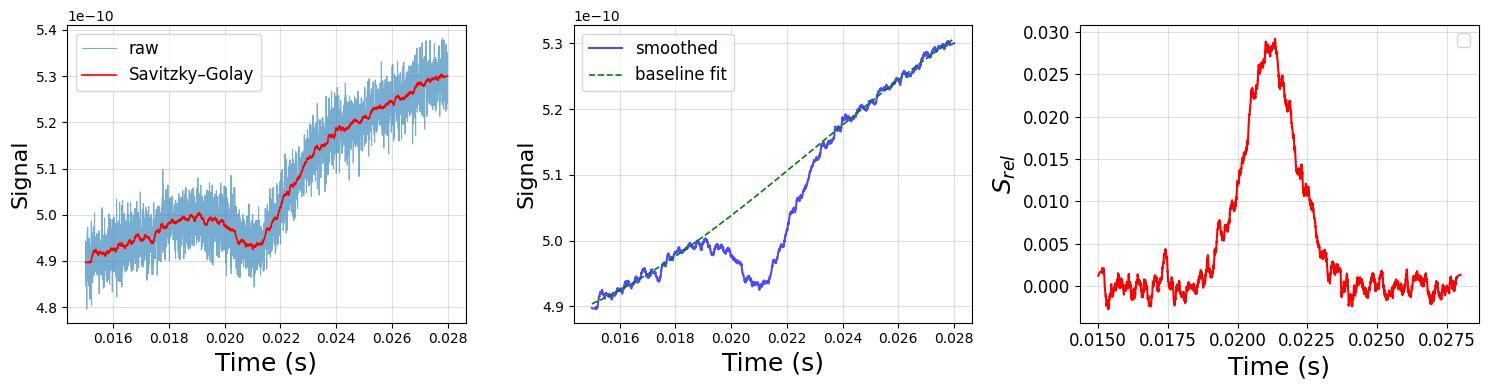

60_45H: norm_dip = 2.9216e-02   s0 = 5.0834e-10   sigma_noise = 3.615e-12



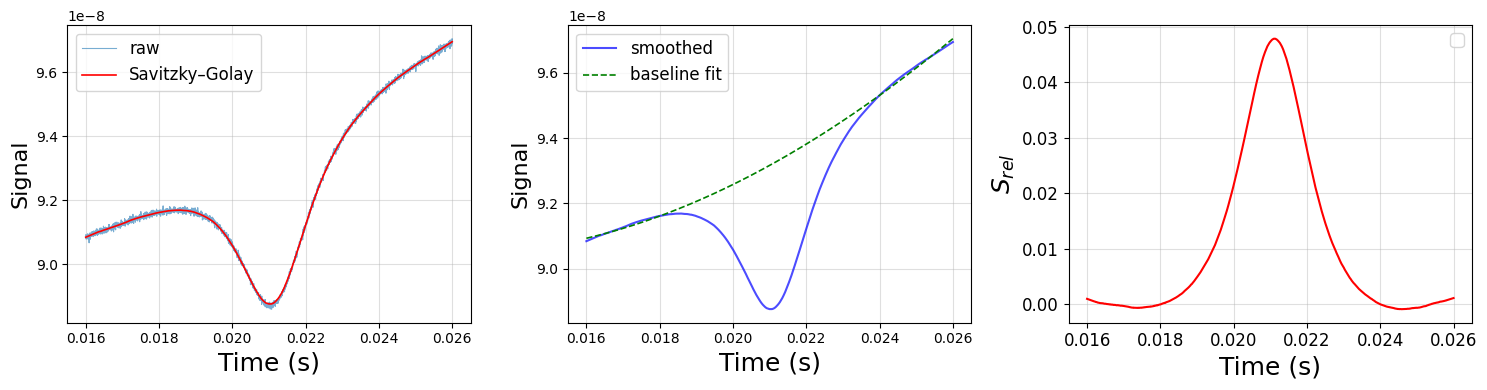

45_60H_ref: norm_dip = 4.7810e-02   s0 = 9.3238e-08   sigma_noise = 5.624e-11



In [ ]:
#Per-dataset processing parameters
PARAMS = {

    '30_45H': dict(start_time=0.016,  end_time=0.026,
                 savgol_window_length=100, savgol_polyorder=1,
                 baseline_fit_fraction=0.25, baseline_poly_degree=3),
    '45_45H': dict(start_time=0.014,  end_time=0.028,
                 savgol_window_length=71, savgol_polyorder=2,
                 baseline_fit_fraction=0.25, baseline_poly_degree=3),
    '60_45H': dict(start_time=0.015,  end_time=0.028,
                 savgol_window_length=71, savgol_polyorder=2,
                 baseline_fit_fraction=0.25, baseline_poly_degree=3),
    '30_60H': dict(start_time=0.016,  end_time=0.026,
                 savgol_window_length=100, savgol_polyorder=1,
                 baseline_fit_fraction=0.25, baseline_poly_degree=3),
    '50_60H': dict(start_time=0.016,  end_time=0.026,
                 savgol_window_length=100, savgol_polyorder=1,
                 baseline_fit_fraction=0.25, baseline_poly_degree=3),
    '45_60H_ref': dict(start_time=0.016,  end_time=0.026,
                 savgol_window_length=100, savgol_polyorder=1,
                 baseline_fit_fraction=0.25, baseline_poly_degree=3),
}

results = {}
for label in ['30_45H','45_45H', '60_45H','45_60H_ref']:
    t, s = raw[label]
    results[label] = process_signal(t, s, **PARAMS[label])
    plot_processing(results[label], label)
    r = results[label]
    print(f'{label:>5s}: norm_dip = {r["norm_dip"]:.4e}   '
          f's0 = {r["s0"]:.4e}   sigma_noise = {r["sigma_noise"]:.3e}')
    print()



   $$\left(\frac{\sigma_d}{d}\right)^2
     = \left(\frac{\sigma_c}{c}\right)^2
     + \left(\frac{\sigma_{s_0}}{s_0}\right)^2 \,.$$



In [ ]:
def normalized_dip_uncertainty(result):
    """Return (norm_dip, sigma_norm_dip) using:
        - σ_c  ≈ σ_noise from baseline regions
        - σ_s0 from polynomial fit covariance at the dip time
        - σ(d)/|d| = sqrt((σ_c/c)**2 + (σ_s0/s0)**2)
    """
    d      = result['norm_dip']
    s0     = result['s0']
    c      = result['corrected'][result['dip_idx']]      # = d * s0
    sigma_c = result['sigma_noise']
    x_dip   = result['baseline_powers']
    sigma_s0 = float(np.sqrt(x_dip @ result['baseline_cov'] @ x_dip))

    rel_var = (sigma_c / c) ** 2 + (sigma_s0 / s0) ** 2
    sigma_d = abs(d) * np.sqrt(rel_var)

    return d, sigma_d, sigma_c, sigma_s0


print(f'{"label":>6s}  {"d":>11s}  {"σ_d":>10s}  '
      f'{"σ_c/c":>9s}  {"σ_s0/s0":>10s}')
print('-' * 56)
norm_dips = {}
sigma_dips = {}
for label in ['30_45H','45_45H', '60_45H','45_60H_ref']:
    d, sd, sc, ss0 = normalized_dip_uncertainty(results[label])
    norm_dips[label]  = d
    sigma_dips[label] = sd
    c = results[label]['corrected'][results[label]['dip_idx']]
    s0 = results[label]['s0']
    print(f'{label:>6s}  {d:11.4e}  {sd:10.3e}  '
          f'{sc/c:9.3e}  {ss0/s0:10.3e}')

 label            d         σ_d      σ_c/c     σ_s0/s0
--------------------------------------------------------
30_45H   3.3895e-03   2.416e-03  7.127e-01   1.672e-05
45_45H   1.5154e-02   4.404e-03  2.906e-01   5.338e-05
60_45H   2.9216e-02   7.112e-03  2.434e-01   7.871e-05
45_60H_ref   4.7810e-02   6.032e-04  1.262e-02   5.418e-05


## 6. Final plot — normalized absorption peak vs source–detector separation

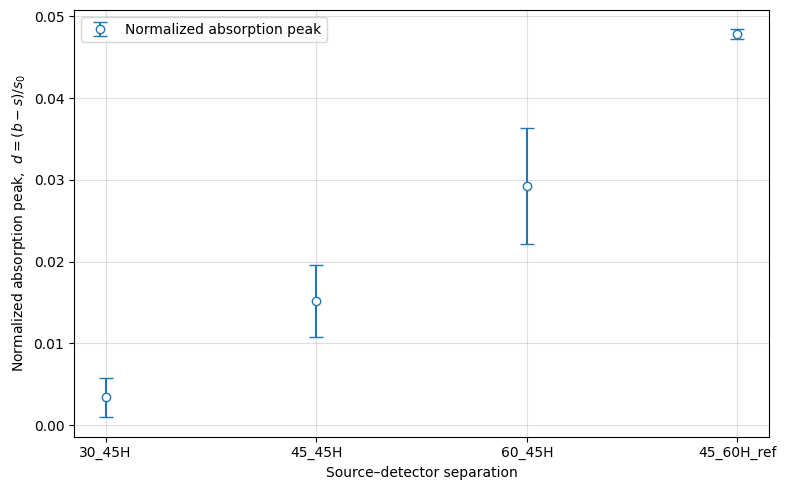


Summary
-------
  30_45H: d = 3.3895e-03  ±  2.416e-03
  45_45H: d = 1.5154e-02  ±  4.404e-03
  60_45H: d = 2.9216e-02  ±  7.112e-03
  45_60H_ref: d = 4.7810e-02  ±  6.032e-04


In [ ]:
order = ['30_45H','45_45H', '60_45H','45_60H_ref']
dips   = np.array([norm_dips[k]  for k in order])
errors = np.array([sigma_dips[k] for k in order])

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(order, dips, yerr=errors,
            fmt='o', capsize=5, color='C0', mfc='white', mec='C0',
            label='Normalized absorption peak')
ax.set_xlabel('Source–detector separation')
ax.set_ylabel('Normalized absorption peak,  $d = (b - s)/s_0$')
#ax.set_title('Normalized O$_2$ A-band absorption — 19 May 2026 (F1 phantom)')
ax.grid(True, alpha=0.4)
ax.legend()
fig.tight_layout()
plt.show()

# Tabulate for the record
print()
print('Summary')
print('-------')
for k in order:
    print(f'  {k:>5s}: d = {norm_dips[k]:.4e}  ±  {sigma_dips[k]:.3e}')

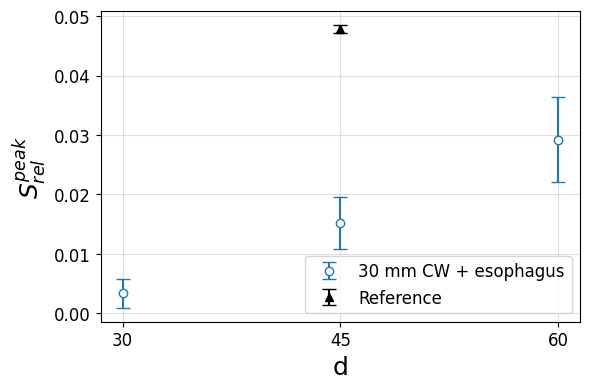


Summary of Batch 1
------------------
   30mm: d = 3.3895e-03  ±  2.416e-03
   45mm: d = 1.5154e-02  ±  4.404e-03
   60mm: d = 2.9216e-02  ±  7.112e-03
   ref: d = 4.7810e-02  ±  6.032e-04


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Reconstruct norm_dips_batch1 and sigma_dips_batch1 from the output of cell 23d6ef85 (before rI2YJZsvTRTL and 7SG8Mm42UFXA)
norm_dips_batch1 = {
    'ref': 4.7810e-02,
    '30mm': 3.3895e-03,
    '45mm': 1.5154e-02,
    '60mm': 2.9216e-02
}
sigma_dips_batch1 = {
    'ref': 6.032e-04,
    '30mm': 2.416e-03,
    '45mm': 4.404e-03,
    '60mm': 7.112e-03
}


# Define the labels for the different separations
separation_keys = ['30mm', '45mm', '60mm']
x_labels_for_plot = [30,45,60]
x_indices = np.arange(len(x_labels_for_plot))

# Extract dips and errors for Batch 1 (original measurements)
dips_batch1_plot = np.array([norm_dips_batch1[k] for k in separation_keys])
errors_batch1_plot = np.array([sigma_dips_batch1[k] for k in separation_keys])


# Extract ref measurement
ref_dip = norm_dips_batch1['ref']
ref_error = sigma_dips_batch1['ref']

fig, ax = plt.subplots(figsize=(6, 4))

# Plot Batch 1
ax.errorbar(x_indices, dips_batch1_plot, yerr=errors_batch1_plot,
            fmt='o', capsize=5, color='C0', mfc='white', mec='C0',
            label='30 mm CW + esophagus')

# Plot 'ref' measurement at the '50 mm' position (index 2)
ax.errorbar([x_indices[1]], [ref_dip], yerr=[ref_error],
            fmt='^', capsize=5, color='k', mfc='k', mec='k',
            label='Reference')

ax.set_xticks(x_indices)
ax.set_xticklabels(x_labels_for_plot)
ax.set_xlabel('d',fontsize=18)
ax.set_ylabel('$S_{rel}^{peak}$',fontsize=18)
#ax.set_title('Normalized absorption ')
ax.grid(True, alpha=0.4)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=12)
fig.tight_layout()
plt.show()

# Tabulate for the record
print()
print('Summary of Batch 1')
print('------------------')
for k in separation_keys:
    print(f'  {k:>5s}: d = {norm_dips_batch1[k]:.4e}  ±  {sigma_dips_batch1[k]:.3e}')
print(f'   ref: d = {norm_dips_batch1["ref"]:.4e}  ±  {sigma_dips_batch1["ref"]:.3e}')
